# **Day 1 — Sprint 2 Planning & Convolutional Neural Networks**

## **Sprint 2 plan**

**Focus:** CNNs, RNNs & TRANSFORMERS
**Sprint Goal:** Learn CNNs for images, RNN/s/LSTMs for sequences and attention mechanism behind Transformers and advance the project's core model.


| Event | Description |
|---|---|
| Sprint Planning - Day 1 | Define Sprint 2 goal abd backlog and incorporating the Sprint 1 retrospective improvement. |
| Daily Standup | 3-munite update about what was completed, what is next, any issues. |
| Mentor Code & Notebook Review - Day 3 | Confirm the Sprint 1 goal from Week 5, select backlog tasks, mentor reviews and commit the sprint goal. |
| Sprint Review - Day 5 | Demo completed stages/results. Incomplete tasks move to Sprint 2. |
| Sprint Retrospective - Day 5 | Sprint 1 wrap-up and one specific action for Sprint 2. |




#### **Sprint 1 Backlog**

| Item | Tasks |
|---|---|
| Item 1 |Sprint 2 planning and buid a foundational understanding of CNNs, convolution, filters and feature maps. |
| Item 2 | Build a fully functional CNN featuring pooling, architecture design and transfer learning using pre trained model to optimize computer vision tasks. |
| Item 3 | Train and evaluate an LSTM on a sequential dataset, and compare LSTM's performance against a plain RNN/non-sequential baseline. |
| Item 4 | Apply a pre-trained Transformer to a text task (via the Hugginf Face pipeline), compare its metrics to Day 3 LSTM and write a short explaination of  attention mechanism vs. RNN's step-by-step memory |
| Item 5 | Advance, tune and evaluate the project's core model. Log all experiments in MLflow, assemble a metrics comparison table, and complete the written sprint Retrospective |


#### **Definition of Done (DoD) & Acceptance Criteria**

- [x] Notebook runs end-to-end without errors.
- [x] All code commited to GitHub via feature branches.
- [x] Mid-sprint mentor feedback is addressed.
- [x] Metrics are logged in a comparison table and the neural network beats the week 6 baseline.
- [x] The pull request is merged after mentor approval.
- [x] Written Sprint Retrospective is completes with one concrete action item for Sprint 2.

## **Why Dense Neural Netwroks fail on Images ?**

An image has **3 channels; Red, Green, Blue (RGB)**. Each image datapoint is represented in 3 dimensions which triples the weights associated with each layer of the neural network. **The huge number of weights creates an overhead**; incresing the network's density and time consumption.

Additionally, an **image's spatial structure is flattened** out by a dense network, scattering pixels and **losing image local pattens**.

---

## **What is Convolution ?**

  Convolution means **sliding a small filter/kernel across an image**. The filter *repeatidly* multiplies the image values by the filter values and adds them together, that is essensially the **dot product**.

  A **filter** is a *small matrix of numbers*. It serves in **detecting specific patterns** such as; edges, curves textures, etc.

  After applying a filter on on image, the result is a new matrix - **feature map** - that **shows where the pattern was found**.

---

### **Stride**
  It is the **number of pixels the filter moves at a time**, Larger stride means smaller output.

---

### **Padding**
  when the filter size is identical to the image size, the pixels around the edges are relatively neglected. Padding adds 0s around the border to process the pixels near the edges and **preserve spatial size**.

---

### **Why CNNs are better for images?**


1.   CNNs incorporate **Parameter sharing**, rather than createing a new filter for every part of the image to cover it entirely, CNNs **use the same filter repeatidly to cover the entire image**. This reduces the number of parameters considerably.
2.   CNNs can recognize a pattern when its location changes - **Translation Invariance**.
3. CNNs **learn complex features progressively** by combining outputs of a single leayer and growing throughout deeper training layers.



## **CNN hand-defined edge-detection filter**

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.signal import convolve2d

In [14]:
from google.colab import files

upload = files.upload()

In [15]:
img = Image.open("ducky.jpg").convert("L")
img_array = np.array(img, dtype=np.float32)/255.0

print("Image shape:", img_array.shape)

Image shape: (337, 236)


*The below Duck image will be used for the CNN task.*

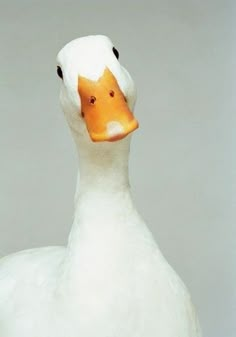

In [21]:
# filter that detects horizontal gradients
edge_kernel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

# fitler that detects vertical gradients
edge_kernel_y = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2,1]
], dtype=np.float32)

# "same" produces the same output size as the input
# "symm" handles edge pixels by mirroring instead of 0 padding - avoids dark border artifact
edge_x = convolve2d(img_array, edge_kernel_x, mode="same", boundary="symm")
edge_y = convolve2d(img_array, edge_kernel_y, mode="same", boundary="symm")

edge_magn = np.sqrt(edge_x**2 + edge_y**2)

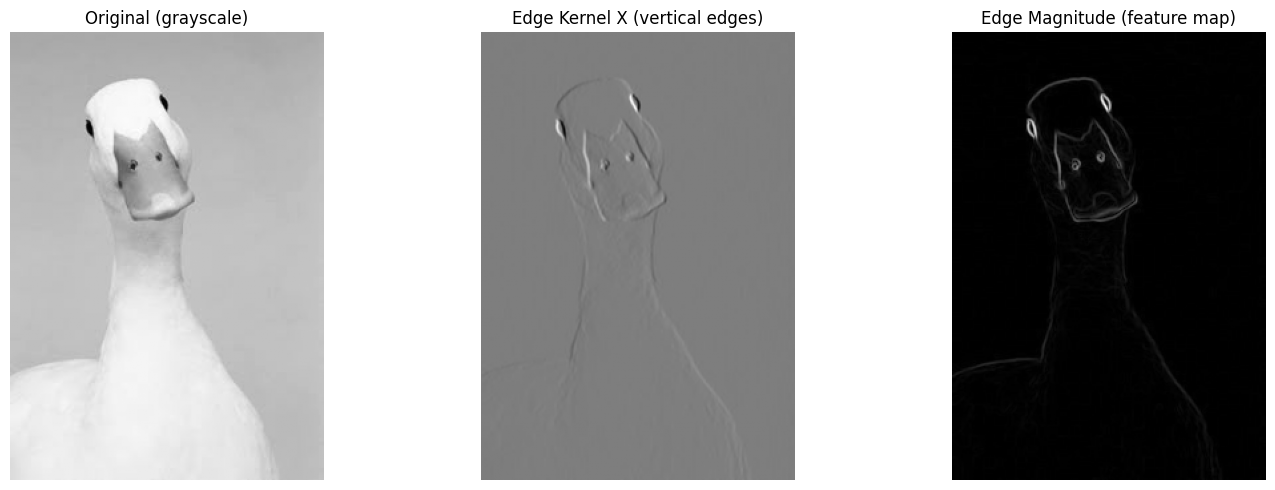

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_array, cmap="gray")
axes[0].set_title("Original (grayscale)")
axes[0].axis("off")

axes[1].imshow(edge_x, cmap="gray")
axes[1].set_title("Edge Kernel X (vertical edges)")
axes[1].axis("off")

axes[2].imshow(edge_magn, cmap="gray")
axes[2].set_title("Edge Magnitude (feature map)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

**Original - grayscale:**
The duck's, head and neck against a flat, light gray background to avoid noisy texture edges outside the duck.

**Sobel X - vertical edges:**
This filter resonds to horizontal gradients - highlights vertical egdes.

**Edge Magnitude - combines Sobel X & Sobel Y:**
Captures gradents in all dimensions. The outline of the duck is a more continuous contour rather than vertical edges. More subtle features are detected.

### **Why the Same Filter Across the Whole Image Needs Far Fewer Weights than a Dense Layer?**

A dense layer **connects every input pixel to every output unit**. A full layer with N output units needs A x B x N weights. For isnatance a 100 x 100 image has 10,000 pixels. A dense layer of 60  units needs around 600,000 parameters for 1 layer.

A convolution fitler, by contrast, slides a small kernel (e.g. 3x3) across the entire image, reusing the same 9 weights at every spacial location. That is because convolution exploits **local connectivity** (each output looks at a smallpatch  of the image not all of it) and. **parameter sharing** (explained earlier in the notebook).

CNNs are *practical* for image data, *where dense layers would be both computationally infeasible* and prone to severe *overfitting* given the parameter count relative to ypical training set sizes.

### **Model Type Decision**

For **2D image data** a **Convolutional Neural Network is preferred** over a Dense Netwok.

**Why ?**
Because the data has spatial structure that needs to be preserved, better texture and shape recognition and reduced calculations time.